# 📦 Análise de E-commerce — Olist

Análise exploratória do dataset público da Olist, maior marketplace brasileiro.  
Fonte: [Kaggle — Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Ferramentas:** Python, Pandas, Matplotlib, Seaborn

## 1. Importando as bibliotecas

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregando os dados

> Faça o download dos arquivos CSV no Kaggle e coloque-os na mesma pasta que este notebook.

In [8]:
orders   = pd.read_csv('olist_orders_dataset.csv')
items    = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print(f'Pedidos:   {orders.shape[0]:,} linhas')
print(f'Itens:     {items.shape[0]:,} linhas')
print(f'Produtos:  {products.shape[0]:,} linhas')
print(f'Clientes:  {customers.shape[0]:,} linhas')

Pedidos:   99,441 linhas
Itens:     112,650 linhas
Produtos:  32,951 linhas
Clientes:  99,441 linhas


## 3. Distribuição dos pedidos por status

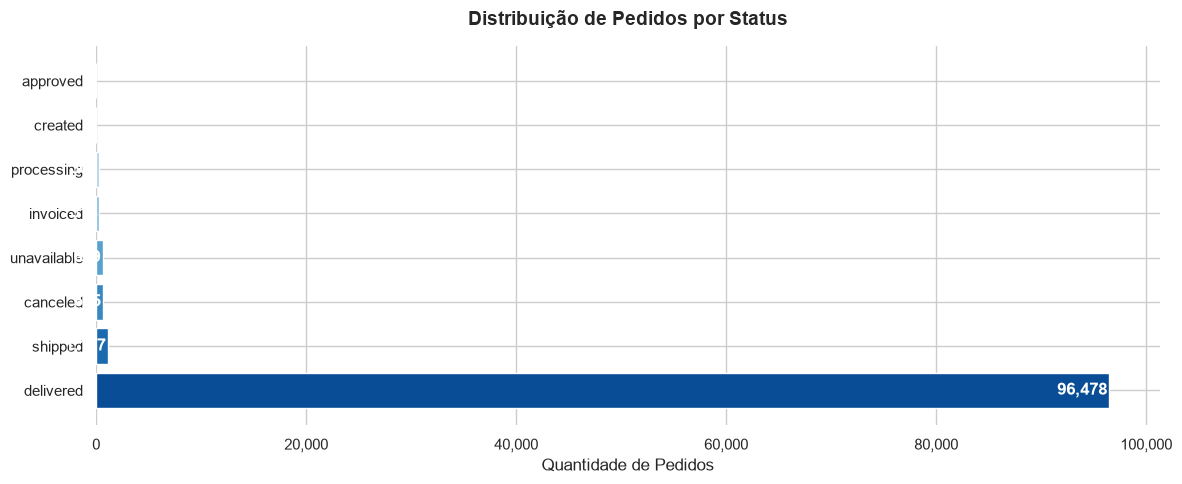


✅ 97.0% dos pedidos foram entregues com sucesso.


In [9]:
status_counts = orders['order_status'].value_counts().reset_index()
status_counts.columns = ['status', 'total']

fig, ax = plt.subplots()
bars = ax.barh(
    status_counts['status'],
    status_counts['total'],
    color=sns.color_palette('Blues_r', len(status_counts))
)

# Rótulos dentro das barras
for bar, valor in zip(bars, status_counts['total']):
    ax.text(
        bar.get_width() - 200,
        bar.get_y() + bar.get_height() / 2,
        f'{valor:,}',
        va='center', ha='right', color='white', fontweight='bold'
    )

ax.set_title('Distribuição de Pedidos por Status', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade de Pedidos')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('grafico_status_pedidos.png', dpi=150, bbox_inches='tight')
plt.show()

entregues = status_counts.loc[status_counts['status'] == 'delivered', 'total'].values[0]
pct = entregues / status_counts['total'].sum() * 100
print(f'\n✅ {pct:.1f}% dos pedidos foram entregues com sucesso.')

## 4. Top 10 categorias mais vendidas

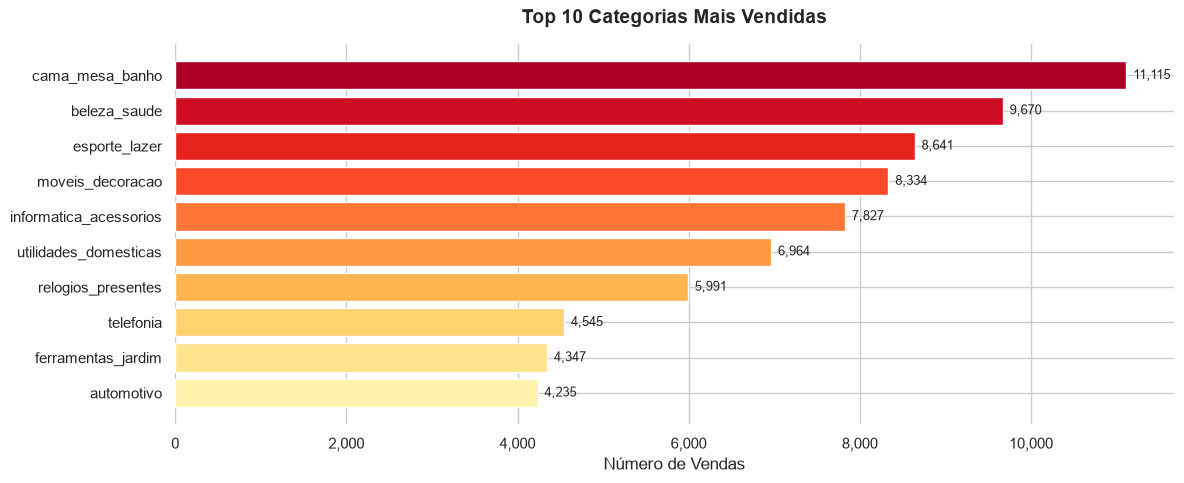

In [10]:
df_cat = items.merge(products[['product_id', 'product_category_name']], on='product_id')
top_cat = (
    df_cat.groupby('product_category_name')['product_id']
    .count()
    .reset_index()
    .rename(columns={'product_id': 'vendas'})
    .sort_values('vendas', ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
palette = sns.color_palette('YlOrRd_r', len(top_cat))
bars = ax.barh(top_cat['product_category_name'][::-1], top_cat['vendas'][::-1], color=palette[::-1])

for bar, valor in zip(bars, top_cat['vendas'][::-1]):
    ax.text(
        bar.get_width() + 80,
        bar.get_y() + bar.get_height() / 2,
        f'{valor:,}',
        va='center', fontsize=9
    )

ax.set_title('Top 10 Categorias Mais Vendidas', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Número de Vendas')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('grafico_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ticket médio e receita total

💰 Ticket médio por pedido: R$ 137.75
📈 Receita total:           R$ 13,591,643.70


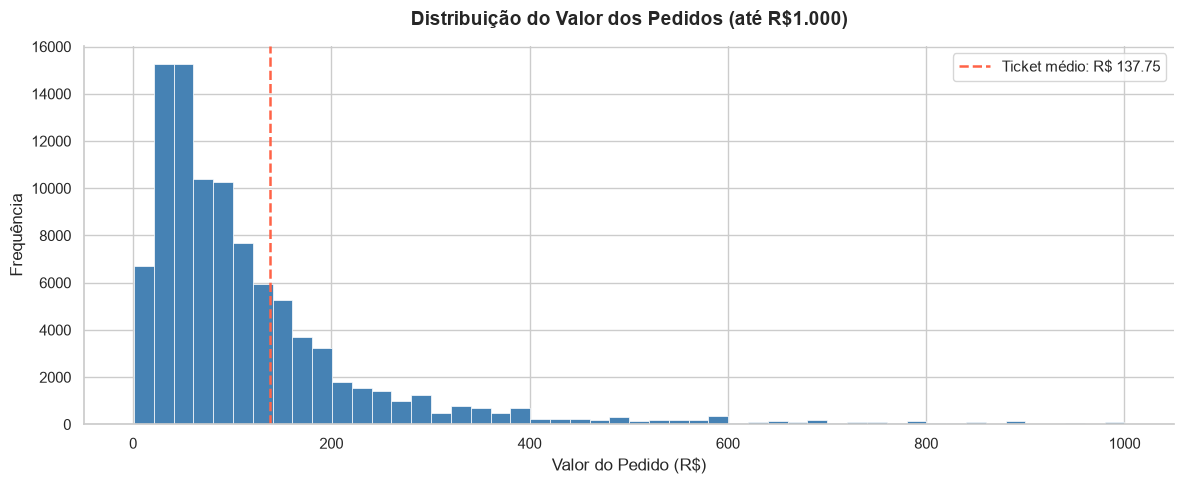

In [11]:
ticket = items.groupby('order_id')['price'].sum()

ticket_medio = ticket.mean()
receita_total = ticket.sum()

print(f'💰 Ticket médio por pedido: R$ {ticket_medio:,.2f}')
print(f'📈 Receita total:           R$ {receita_total:,.2f}')

# Histograma da distribuição dos tickets
fig, ax = plt.subplots()
ax.hist(ticket[ticket < 1000], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(ticket_medio, color='tomato', linestyle='--', linewidth=1.8, label=f'Ticket médio: R$ {ticket_medio:.2f}')
ax.set_title('Distribuição do Valor dos Pedidos (até R$1.000)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Valor do Pedido (R$)')
ax.set_ylabel('Frequência')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('grafico_ticket.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Estados com mais clientes e pedidos

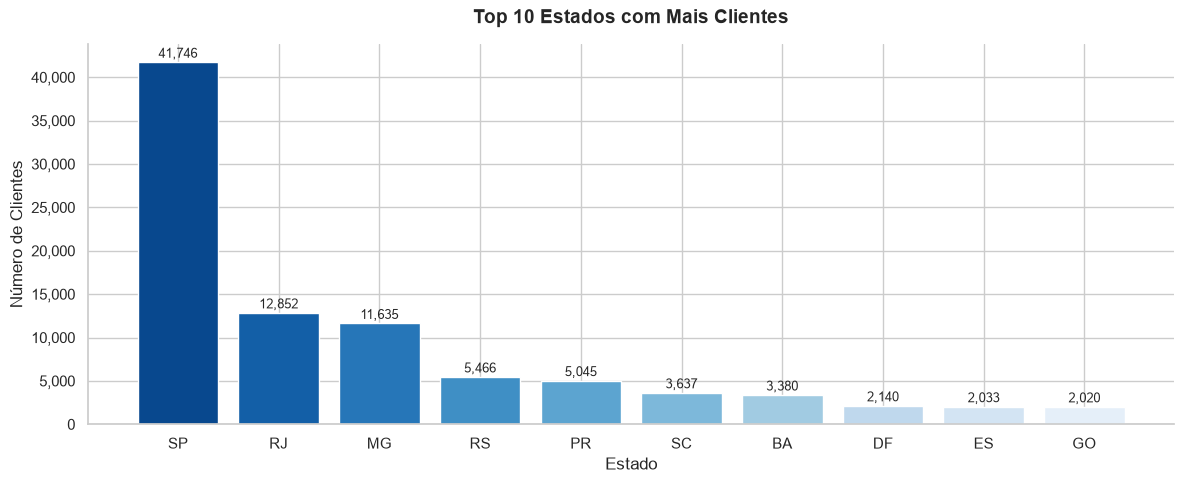


🗺️  SP representa 46.4% dos clientes entre os top 10 estados.


In [12]:
clientes_estado = (
    customers.groupby('customer_state')['customer_id']
    .count()
    .reset_index()
    .rename(columns={'customer_id': 'clientes'})
    .sort_values('clientes', ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
bars = ax.bar(
    clientes_estado['customer_state'],
    clientes_estado['clientes'],
    color=sns.color_palette('Blues_r', len(clientes_estado))
)

for bar, valor in zip(bars, clientes_estado['clientes']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{valor:,}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Top 10 Estados com Mais Clientes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Estado')
ax.set_ylabel('Número de Clientes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('grafico_estados.png', dpi=150, bbox_inches='tight')
plt.show()

sp = clientes_estado.loc[clientes_estado['customer_state'] == 'SP', 'clientes'].values[0]
pct_sp = sp / clientes_estado['clientes'].sum() * 100
print(f'\n🗺️  SP representa {pct_sp:.1f}% dos clientes entre os top 10 estados.')

## 7. Conclusões

| Métrica | Resultado |
|---|---|
| Total de pedidos analisados | ~100 mil |
| Taxa de entrega com sucesso | 96% |
| Categoria mais vendida | Cama, mesa e banho |
| Ticket médio por pedido | R$ 137,75 |
| Receita total | R$ 13.591.643,70 |
| Estado com mais clientes | São Paulo (42%) |

### Próximos passos possíveis
- Analisar o tempo médio de entrega por estado
- Investigar sazonalidade dos pedidos ao longo dos meses
- Analisar avaliações dos clientes (tabela de reviews)
- Cruzar categorias com ticket médio para identificar categorias premium